# Tratamento da Estação São Cristóvão

Este notebook organiza o tratamento horário da Estação `São Cristóvão` em três blocos simples:

1. Padronizar o calendário horário;
2. Interpolar apenas lacunas internas curtas;
3. Validar o impacto do tratamento.

A proposta aqui é fazer o básico bem feito, de forma rastreável e reutilizável para as próximas estações.


## Bibliotecas e configurações

Começamos carregando as bibliotecas que serão usadas ao longo do notebook e localizando automaticamente a raiz do projeto. Isso evita depender do diretório manual de execução do notebook.


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from decimal import Decimal, ROUND_HALF_EVEN

## Carregamento da base da estação

Nesta etapa, carregamos a base consolidada de qualidade do ar, normalizamos o nome da estação para evitar problemas de codificação e isolamos apenas os registros da estação `São Cristóvão`.


In [2]:
url_air_quality_data = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/MonitorAr/InitialMergedData/merged_air_quality_data.csv"

df_air_quality = pd.read_csv(url_air_quality_data)
df_sao_cristovao = df_air_quality[df_air_quality["Nome"] == "ESTAÇÃO SÃO CRISTÓVÃO"].copy()

df_sao_cristovao["data"] = pd.to_datetime(df_sao_cristovao["data"])
df_sao_cristovao = df_sao_cristovao.sort_values("data").reset_index(drop=True)
df_sao_cristovao = df_sao_cristovao.drop_duplicates(subset="data", keep="first")
df_sao_cristovao = df_sao_cristovao.set_index("data").sort_index().copy()

print("Dimensoes da base da Estacao São Cristóvão:", df_sao_cristovao.shape)
display(df_sao_cristovao.head())

Dimensoes da base da Estacao São Cristóvão: (61368, 14)


,Nome,chuva,temp,ur,so2,no2,co,no,nox,o3,pm10,pm2_5,lat,lon
data,,,,,,,,,,,,,,
2012-01-01 00:30:00,ESTAÇÃO SÃO CRISTÓVÃO,0.2,27.14,99.82,8.41,NaN,0.17,NaN,NaN,10.95,49.0,NaN,-22.897771,-43.221745
2012-01-01 01:30:00,ESTAÇÃO SÃO CRISTÓVÃO,0.4,27.01,99.82,4.77,NaN,0.21,NaN,NaN,10.01,27.0,NaN,-22.897771,-43.221745
2012-01-01 02:30:00,ESTAÇÃO SÃO CRISTÓVÃO,0.0,26.63,99.81,4.31,NaN,0.25,NaN,NaN,3.63,32.0,NaN,-22.897771,-43.221745
2012-01-01 03:30:00,ESTAÇÃO SÃO CRISTÓVÃO,0.0,26.53,99.82,3.41,NaN,0.18,NaN,NaN,1.92,13.0,NaN,-22.897771,-43.221745
2012-01-01 04:30:00,ESTAÇÃO SÃO CRISTÓVÃO,0.2,26.62,99.81,4.56,NaN,0.18,NaN,NaN,3.80,9.0,NaN,-22.897771,-43.221745


## Resumo das faltas antes do tratamento

Com o calendário padronizado, agora medimos o tamanho do problema de dados faltantes antes de qualquer imputação. Essa tabela serve como linha de base para comparar o efeito do tratamento depois.


In [3]:
variaveis_ambientais = [
'no',
'no2',
'so2',
'pm2_5',
'nox',
'ur',
'temp',
'o3',
'co',
'pm10',
'chuva'
]
    

def resumir_faltantes(df: pd.DataFrame, variaveis: list[str]) -> pd.DataFrame:
    total_linhas = len(df)
    resumo = pd.DataFrame(index=variaveis)
    resumo["faltantes"] = [int(df[col].isna().sum()) for col in variaveis]
    resumo["missing_pct"] = [round(100 * df[col].isna().mean(), 2) for col in variaveis]
    resumo["validos"] = total_linhas - resumo["faltantes"]
    return resumo.sort_values("faltantes", ascending=False)


resumo_missing_antes = resumir_faltantes(df_sao_cristovao, variaveis_ambientais)
display(resumo_missing_antes)

,faltantes,missing_pct,validos
no,61368,100.00,0
no2,61368,100.00,0
pm2_5,61368,100.00,0
nox,61368,100.00,0
so2,6754,11.01,54614
ur,6178,10.07,55190
co,4897,7.98,56471
temp,4327,7.05,57041
pm10,3512,5.72,57856
o3,3270,5.33,58098


## Regra de imputação adotada

O tratamento escolhido aqui é propositalmente conservador:

- Interpolar apenas lacunas internas de até `4` horas consecutivas;
- Não extrapolar bordas da série;
- Não interpolar `chuva`, porque a interpolação linear pode criar eventos artificiais.

Com isso, preservamos a rastreabilidade do tratamento e evitamos preencher ausências longas ou estruturalmente mais problemáticas.


In [4]:
MAX_GAP_HORAS = 4

variaveis_interpolar = [
    "temp",
    "ur",
    "so2",
    "no2",
    "co",
    "no",
    "nox",
    "o3",
    "pm10",
    "pm2_5",
]


def mascara_lacunas_internas_curtas(serie: pd.Series, max_gap: int = 4) -> pd.Series:
    faltante = serie.isna()
    if not faltante.any():
        return pd.Series(False, index=serie.index)

    grupos = faltante.ne(faltante.shift(fill_value=False)).cumsum()
    tamanho_grupo = faltante.groupby(grupos).transform("sum")
    tem_valor_antes = serie.ffill().notna()
    tem_valor_depois = serie.bfill().notna()

    return faltante & tem_valor_antes & tem_valor_depois & (tamanho_grupo <= max_gap)

df_sao_cristovao_tratado = df_sao_cristovao.copy()

registros_imputacao = []

for variavel in variaveis_ambientais:
    serie_original = df_sao_cristovao[variavel]

    if variavel in variaveis_interpolar:
        mascara_gap_curto = mascara_lacunas_internas_curtas(serie_original, max_gap=MAX_GAP_HORAS)
        serie_interpolada = serie_original.interpolate(method="time", limit_area="inside")
        df_sao_cristovao_tratado.loc[mascara_gap_curto, variavel] = serie_interpolada.loc[mascara_gap_curto]
        valores_imputados = int((mascara_gap_curto & serie_interpolada.notna()).sum())
        metodo = "interpolate_time"

    else:
        mascara_gap_curto = pd.Series(False, index=serie_original.index)
        valores_imputados = 0
        metodo = "sem_interpolacao"



    registros_imputacao.append(
        {
            "variavel": variavel,
            "metodo": metodo,
            "faltantes_antes": int(serie_original.isna().sum()),
            "faltantes_depois": int(df_sao_cristovao_tratado[variavel].isna().sum()),
            "valores_imputados": valores_imputados,
        }
    )

resumo_imputacao = pd.DataFrame(registros_imputacao).sort_values(
    ["valores_imputados", "faltantes_antes"],
    ascending=[False, False],
)

display(resumo_imputacao)

,variavel,metodo,faltantes_antes,faltantes_depois,valores_imputados
2,so2,interpolate_time,6754,5233,1521
8,co,interpolate_time,4897,4147,750
7,o3,interpolate_time,3270,2820,450
9,pm10,interpolate_time,3512,3067,445
5,ur,interpolate_time,6178,5900,278
6,temp,interpolate_time,4327,4071,256
0,no,interpolate_time,61368,61368,0
1,no2,interpolate_time,61368,61368,0
3,pm2_5,interpolate_time,61368,61368,0
4,nox,interpolate_time,61368,61368,0


## Validação do impacto do tratamento

Depois da imputação, validamos o impacto em duas frentes:

- Redução dos dados faltantes por variável;
- Estabilidade de estatísticas básicas antes e depois do tratamento.

Como a regra de imputação é curta e conservadora, a expectativa é reduzir parte das lacunas sem alterar, de forma relevante, o comportamento geral das séries.


Total de valores imputados: 3700


,faltantes_antes,missing_pct_antes,faltantes_depois,missing_pct_depois,reducao_absoluta,reducao_relativa_pct
so2,6754,11.01,5233,8.53,1521,22.52
co,4897,7.98,4147,6.76,750,15.32
o3,3270,5.33,2820,4.60,450,13.76
pm10,3512,5.72,3067,5.00,445,12.67
ur,6178,10.07,5900,9.61,278,4.50
temp,4327,7.05,4071,6.63,256,5.92
no,61368,100.00,61368,100.00,0,0.00
pm2_5,61368,100.00,61368,100.00,0,0.00
no2,61368,100.00,61368,100.00,0,0.00
nox,61368,100.00,61368,100.00,0,0.00


,media_antes,mediana_antes,desvio_padrao_antes,media_depois,mediana_depois,desvio_padrao_depois,delta_media,delta_desvio_padrao
so2,8.489994,5.34,10.318167,8.512074,5.36,10.339938,0.022080,0.021771
ur,71.991330,73.33,17.202131,71.989494,73.33,17.203843,-0.001836,0.001712
temp,26.644530,26.12,4.787478,26.644156,26.12,4.791063,-0.000374,0.003584
o3,21.805289,12.76,24.788561,21.876009,12.90,24.794181,0.070720,0.005621
co,0.262735,0.15,0.352640,0.263003,0.15,0.352419,0.000268,-0.000221
pm10,33.754114,29.00,22.057656,33.767594,29.00,22.061772,0.013480,0.004116
chuva,0.093074,0.00,0.849118,0.093074,0.00,0.849118,0.000000,0.000000


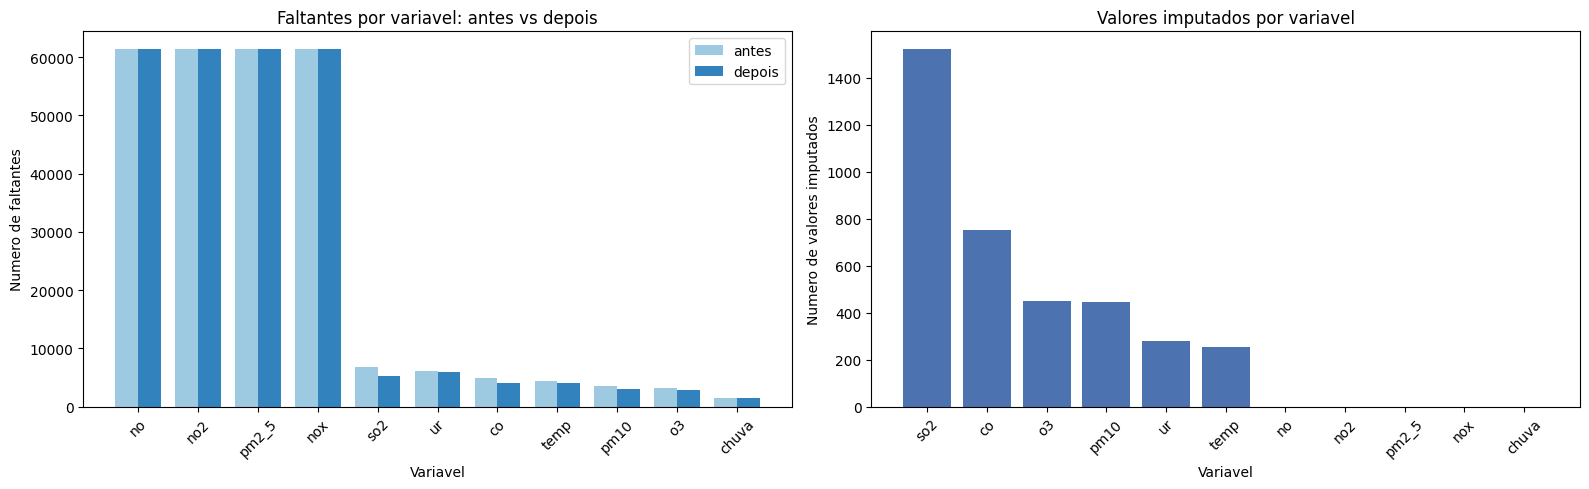

In [5]:
def estatisticas_basicas(df: pd.DataFrame, variaveis: list[str]) -> pd.DataFrame:
    resumo = pd.DataFrame(index=variaveis)
    resumo["media"] = [df[col].mean() for col in variaveis]
    resumo["mediana"] = [df[col].median() for col in variaveis]
    resumo["desvio_padrao"] = [df[col].std() for col in variaveis]
    return resumo


resumo_missing_depois = resumir_faltantes(df_sao_cristovao_tratado, variaveis_ambientais)

comparativo_missing = resumo_missing_antes[["faltantes", "missing_pct"]].rename(
    columns={
        "faltantes": "faltantes_antes",
        "missing_pct": "missing_pct_antes",
    }
).join(
    resumo_missing_depois[["faltantes", "missing_pct"]].rename(
        columns={
            "faltantes": "faltantes_depois",
            "missing_pct": "missing_pct_depois",
        }
    )
)
comparativo_missing["reducao_absoluta"] = (
    comparativo_missing["faltantes_antes"] - comparativo_missing["faltantes_depois"]
)
comparativo_missing["reducao_relativa_pct"] = (
    100 * comparativo_missing["reducao_absoluta"] / comparativo_missing["faltantes_antes"].replace(0, pd.NA)
).round(2)

variaveis_com_dados = [
    variavel
    for variavel in variaveis_ambientais
    if df_sao_cristovao[variavel].notna().any() or df_sao_cristovao_tratado[variavel].notna().any()
]

estatisticas_antes = estatisticas_basicas(df_sao_cristovao, variaveis_com_dados).add_suffix("_antes")
estatisticas_depois = estatisticas_basicas(df_sao_cristovao_tratado, variaveis_com_dados).add_suffix("_depois")
comparativo_estatistico = estatisticas_antes.join(estatisticas_depois)
comparativo_estatistico["delta_media"] = (
    comparativo_estatistico["media_depois"] - comparativo_estatistico["media_antes"]
)
comparativo_estatistico["delta_desvio_padrao"] = (
    comparativo_estatistico["desvio_padrao_depois"] - comparativo_estatistico["desvio_padrao_antes"]
)

print(f"Total de valores imputados: {int(resumo_imputacao['valores_imputados'].sum())}")
display(comparativo_missing.sort_values("reducao_absoluta", ascending=False))
display(comparativo_estatistico)

comparativo_missing_plot = comparativo_missing.reset_index(names="variavel")
resumo_imputacao_plot = resumo_imputacao.sort_values("valores_imputados", ascending=False)

x_missing = range(len(comparativo_missing_plot))
largura = 0.38
x_imputacao = range(len(resumo_imputacao_plot))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(
    [x - largura / 2 for x in x_missing],
    comparativo_missing_plot["faltantes_antes"],
    width=largura,
    label="antes",
    color="#9ecae1",
)
axes[0].bar(
    [x + largura / 2 for x in x_missing],
    comparativo_missing_plot["faltantes_depois"],
    width=largura,
    label="depois",
    color="#3182bd",
)
axes[0].set_title("Faltantes por variavel: antes vs depois")
axes[0].set_xlabel("Variavel")
axes[0].set_ylabel("Numero de faltantes")
axes[0].set_xticks(list(x_missing))
axes[0].set_xticklabels(comparativo_missing_plot["variavel"], rotation=45)
axes[0].legend()

axes[1].bar(
    list(x_imputacao),
    resumo_imputacao_plot["valores_imputados"],
    color="#4c72b0",
)
axes[1].set_title("Valores imputados por variavel")
axes[1].set_xlabel("Variavel")
axes[1].set_ylabel("Numero de valores imputados")
axes[1].set_xticks(list(x_imputacao))
axes[1].set_xticklabels(resumo_imputacao_plot["variavel"], rotation=45)

plt.tight_layout()
plt.show()

## Calculo do Indice de Qualidade do Ar (AQI)

Nesta etapa, calculamos o AQI diario da estacao com base no documento tecnico de janeiro/2025 (IQAr), alinhado a Resolucao Conama no 506/2024.

### 1) Premissas regulatorias adotadas

Usamos a mesma logica descrita no documento:

- Calculamos um subindice por poluente (`pm10`, `pm2_5`, `o3`, `co`, `no2`, `so2`);
- O AQI diario e o maior subindice do dia;
- `o3` e `co`: maxima da media movel de 8 horas no dia;
- `no2`: maxima horaria no dia;
- `pm10`, `pm2_5` e `so2`: media de 24 horas;
- Arredondamento bancario (`ROUND_HALF_EVEN`):
  - `co` com 1 casa decimal;
  - demais poluentes sem casa decimal;
  - indice final arredondado para inteiro.

### 2) Tabela de faixas e implementacao

As faixas abaixo reproduzem o Quadro 1 do documento e sao aplicadas na interpolacao linear do indice em cada intervalo.


In [6]:
# Faixas de concentracao e indice (IQAr) conforme orientacao tecnica (jan/2025).
FAIXAS_IQAR = {
    'pm10_24h': [
        {'c_ini': 0, 'c_fin': 45, 'i_ini': 0, 'i_fin': 40},
        {'c_ini': 46, 'c_fin': 100, 'i_ini': 41, 'i_fin': 80},
        {'c_ini': 101, 'c_fin': 150, 'i_ini': 81, 'i_fin': 120},
        {'c_ini': 151, 'c_fin': 250, 'i_ini': 121, 'i_fin': 200},
        {'c_ini': 251, 'c_fin': 600, 'i_ini': 201, 'i_fin': 400},
    ],
    'pm2_5_24h': [
        {'c_ini': 0, 'c_fin': 15, 'i_ini': 0, 'i_fin': 40},
        {'c_ini': 16, 'c_fin': 50, 'i_ini': 41, 'i_fin': 80},
        {'c_ini': 51, 'c_fin': 75, 'i_ini': 81, 'i_fin': 120},
        {'c_ini': 76, 'c_fin': 125, 'i_ini': 121, 'i_fin': 200},
        {'c_ini': 126, 'c_fin': 300, 'i_ini': 201, 'i_fin': 400},
    ],
    'o3_8h_max': [
        {'c_ini': 0, 'c_fin': 100, 'i_ini': 0, 'i_fin': 40},
        {'c_ini': 101, 'c_fin': 130, 'i_ini': 41, 'i_fin': 80},
        {'c_ini': 131, 'c_fin': 160, 'i_ini': 81, 'i_fin': 120},
        {'c_ini': 161, 'c_fin': 200, 'i_ini': 121, 'i_fin': 200},
        {'c_ini': 201, 'c_fin': 800, 'i_ini': 201, 'i_fin': 400},
    ],
    'co_8h_max': [
        {'c_ini': 0.0, 'c_fin': 9.0, 'i_ini': 0, 'i_fin': 40},
        {'c_ini': 9.1, 'c_fin': 11.0, 'i_ini': 41, 'i_fin': 80},
        {'c_ini': 11.1, 'c_fin': 13.0, 'i_ini': 81, 'i_fin': 120},
        {'c_ini': 13.1, 'c_fin': 15.0, 'i_ini': 121, 'i_fin': 200},
        {'c_ini': 15.1, 'c_fin': 50.0, 'i_ini': 201, 'i_fin': 400},
    ],
    'no2_1h_max': [
        {'c_ini': 0, 'c_fin': 200, 'i_ini': 0, 'i_fin': 40},
        {'c_ini': 201, 'c_fin': 240, 'i_ini': 41, 'i_fin': 80},
        {'c_ini': 241, 'c_fin': 320, 'i_ini': 81, 'i_fin': 120},
        {'c_ini': 321, 'c_fin': 1130, 'i_ini': 121, 'i_fin': 200},
        {'c_ini': 1131, 'c_fin': 3750, 'i_ini': 201, 'i_fin': 400},
    ],
    'so2_24h': [
        {'c_ini': 0, 'c_fin': 40, 'i_ini': 0, 'i_fin': 40},
        {'c_ini': 41, 'c_fin': 50, 'i_ini': 41, 'i_fin': 80},
        {'c_ini': 51, 'c_fin': 125, 'i_ini': 81, 'i_fin': 120},
        {'c_ini': 126, 'c_fin': 800, 'i_ini': 121, 'i_fin': 200},
        {'c_ini': 801, 'c_fin': 2620, 'i_ini': 201, 'i_fin': 400},
    ],
}

def arredondar_bancario(valor: float, casas_decimais: int):
    """Aplica arredondamento ROUND_HALF_EVEN (arredondamento bancario)."""
    if pd.isna(valor):
        return pd.NA

    quantizador = Decimal('1') if casas_decimais == 0 else Decimal('0.1')
    valor_decimal = Decimal(str(valor)).quantize(quantizador, rounding=ROUND_HALF_EVEN)

    if casas_decimais == 0:
        return int(valor_decimal)
    return float(valor_decimal)

def calcular_subindice_iqar(concentracao: float, faixas: list[dict]):
    """Calcula o subindice de um poluente por interpolacao linear na faixa correspondente."""
    if pd.isna(concentracao):
        return pd.NA

    for faixa in faixas:
        if faixa['c_ini'] <= concentracao <= faixa['c_fin']:
            inclinacao = (faixa['i_fin'] - faixa['i_ini']) / (faixa['c_fin'] - faixa['c_ini'])
            indice = faixa['i_ini'] + inclinacao * (concentracao - faixa['c_ini'])
            return int(Decimal(str(indice)).quantize(Decimal('1'), rounding=ROUND_HALF_EVEN))

    # O Quadro 1 vai ate IQAr=400 (N5 - Pessima); acima do teto, saturamos no valor maximo.
    if concentracao > faixas[-1]['c_fin']:
        return 400

    return pd.NA

def classificar_iqar(indice: float):
    """Converte o indice numerico em faixa textual de qualidade do ar."""
    if pd.isna(indice):
        return pd.NA

    indice_int = int(indice)
    if indice_int <= 40:
        return 'N1 - Boa'
    if indice_int <= 80:
        return 'N2 - Moderada'
    if indice_int <= 120:
        return 'N3 - Ruim'
    if indice_int <= 200:
        return 'N4 - Muito Ruim'
    return 'N5 - Pessima'

def identificar_poluente_dominante(linha_subindices: pd.Series):
    """Retorna o poluente com maior subindice no dia."""
    validos = linha_subindices.dropna()
    if validos.empty:
        return pd.NA
    return validos.idxmax().replace('subindice_', '')

# Metricas diarias de entrada para o IQAr.
metricas_iqar_diarias = pd.DataFrame(index=df_sao_cristovao_tratado.resample('D').size().index)
metricas_iqar_diarias['pm10_24h'] = df_sao_cristovao_tratado['pm10'].resample('D').mean()
metricas_iqar_diarias['pm2_5_24h'] = df_sao_cristovao_tratado['pm2_5'].resample('D').mean()
metricas_iqar_diarias['so2_24h'] = df_sao_cristovao_tratado['so2'].resample('D').mean()
metricas_iqar_diarias['no2_1h_max'] = df_sao_cristovao_tratado['no2'].resample('D').max()

# Para O3 e CO, usamos a maxima da media movel de 8h em cada dia.
metricas_iqar_diarias['o3_8h_max'] = (
    df_sao_cristovao_tratado['o3']
    .rolling(window=8, min_periods=8)
    .mean()
    .resample('D')
    .max()
)
metricas_iqar_diarias['co_8h_max'] = (
    df_sao_cristovao_tratado['co']
    .rolling(window=8, min_periods=8)
    .mean()
    .resample('D')
    .max()
)

# Padronizacao de arredondamento antes do calculo dos indices.
for coluna in ['pm10_24h', 'pm2_5_24h', 'o3_8h_max', 'no2_1h_max', 'so2_24h']:
    metricas_iqar_diarias[coluna] = metricas_iqar_diarias[coluna].apply(
        lambda valor: arredondar_bancario(valor, casas_decimais=0)
    )

metricas_iqar_diarias['co_8h_max'] = metricas_iqar_diarias['co_8h_max'].apply(
    lambda valor: arredondar_bancario(valor, casas_decimais=1)
)

# Calculo dos subindices por poluente.
mapeamento_subindices = {
    'pm10_24h': 'subindice_pm10',
    'pm2_5_24h': 'subindice_pm2_5',
    'o3_8h_max': 'subindice_o3',
    'co_8h_max': 'subindice_co',
    'no2_1h_max': 'subindice_no2',
    'so2_24h': 'subindice_so2',
}

subindices_iqar_diarios = pd.DataFrame(index=metricas_iqar_diarias.index)
for metrica, coluna_subindice in mapeamento_subindices.items():
    subindices_iqar_diarios[coluna_subindice] = metricas_iqar_diarias[metrica].apply(
        lambda concentracao: calcular_subindice_iqar(concentracao, FAIXAS_IQAR[metrica])
    )

# AQI diario = maior subindice entre os poluentes monitorados.
resumo_aqi_diario = pd.DataFrame(index=subindices_iqar_diarios.index)
resumo_aqi_diario['aqi'] = (
    subindices_iqar_diarios
    .apply(pd.to_numeric, errors='coerce')
    .max(axis=1, skipna=True)
    .astype('Int64')
)
resumo_aqi_diario['aqi_qualidade'] = resumo_aqi_diario['aqi'].apply(classificar_iqar)
resumo_aqi_diario['aqi_poluente_dominante'] = subindices_iqar_diarios.apply(
    identificar_poluente_dominante,
    axis=1,
)

display(resumo_aqi_diario.head())
display(subindices_iqar_diarios.head())


,aqi,aqi_qualidade,aqi_poluente_dominante
data,,,
2012-01-01,17,N1 - Boa,pm10
2012-01-02,10,N1 - Boa,pm10
2012-01-03,20,N1 - Boa,pm10
2012-01-04,23,N1 - Boa,pm10
2012-01-05,26,N1 - Boa,o3


,subindice_pm10,subindice_pm2_5,subindice_o3,subindice_co,subindice_no2,subindice_so2
data,,,,,,
2012-01-01,17,<NA>,10,3,<NA>,6
2012-01-02,10,<NA>,7,2,<NA>,5
2012-01-03,20,<NA>,15,1,<NA>,7
2012-01-04,23,<NA>,18,1,<NA>,3
2012-01-05,22,<NA>,26,1,<NA>,7


## Salvamento da base tratada

Por fim, salvamos a Estação `São Cristóvão`:

- Série diária agregada (média para as variáveis e soma diária para `chuva`).

Essa saída já ficam prontas para reutilização nas próximas etapas da pipeline.


In [7]:
project_root = Path().resolve().parents[4]
output_dir = project_root / "Data" / "IntermediaryData" / "MonitorAr" / "TreatedStations"
output_dir.mkdir(parents=True, exist_ok=True)

# Saída diária agregada:
# - média para a maior parte das variáveis
# - soma para chuva (preservando NaN quando o dia inteiro está faltante)

def somar_chuva_diaria(serie: pd.Series) -> float:
    return serie.sum(min_count=1)

agregacoes_diarias = {
    variavel: "mean"
    for variavel in variaveis_ambientais
    if variavel != "chuva"
}
agregacoes_diarias["chuva"] = somar_chuva_diaria

df_sao_cristovao_diario = (
    df_sao_cristovao_tratado[variaveis_ambientais]
    .resample("D")
    .agg(agregacoes_diarias)
)

# Incluimos o AQI diario e a classificacao de qualidade do ar calculados na secao anterior.
colunas_aqi_exportacao = resumo_aqi_diario[["aqi", "aqi_qualidade"]].rename(
    columns={"aqi_qualidade": "qualidade_do_ar"}
)
df_sao_cristovao_diario = df_sao_cristovao_diario.join(colunas_aqi_exportacao, how="left")

df_sao_cristovao_diario_saida = df_sao_cristovao_diario.reset_index()
output_csv_diario_path = output_dir / "sao_cristovao_tratado_diario.csv"
df_sao_cristovao_diario_saida.to_csv(output_csv_diario_path, index=False, encoding="utf-8")

print(f"Arquivo diario salvo em: {output_csv_diario_path}")
display(df_sao_cristovao_diario_saida.head())


Arquivo diario salvo em: C:\Users\jhter\OneDrive - cefet-rj.br\Projetos-2026\qualiar\Data\IntermediaryData\MonitorAr\TreatedStations\sao_cristovao_tratado_diario.csv


,data,no,no2,so2,pm2_5,nox,ur,temp,o3,co,pm10,chuva,aqi,qualidade_do_ar
0,2012-01-01,NaN,NaN,6.166667,NaN,NaN,98.108333,28.402917,14.083333,0.355417,19.291667,23.0,17,N1 - Boa
1,2012-01-02,NaN,NaN,4.550417,NaN,NaN,99.810417,24.518750,7.682917,0.268333,10.666667,52.2,10,N1 - Boa
2,2012-01-03,NaN,NaN,6.644583,NaN,NaN,79.137500,27.532083,17.041250,0.168750,21.729167,0.0,20,N1 - Boa
3,2012-01-04,NaN,NaN,2.858333,NaN,NaN,77.986667,28.378333,19.581250,0.160000,25.666667,0.0,23,N1 - Boa
4,2012-01-05,NaN,NaN,6.823750,NaN,NaN,83.215000,28.946250,33.692083,0.143750,25.208333,0.0,26,N1 - Boa


## Resumo interpretativo do tratamento

O tratamento aplicado na estação `São Cristóvão` manteve uma estratégia conservadora (interpolação temporal em lacunas curtas, até `4` horas) e aumentou a completude sem alterar, de forma relevante, o comportamento geral das séries. No total, foram imputados `3700` valores, com maior contribuição em `so2` (`1521`), `co` (`750`), `o3` (`450`) e `pm10` (`445`), além de ganhos em `ur` (`278`) e `temp` (`256`).

As reduções de dados faltantes foram mais evidentes em `so2` (`11,01%` para `8,53%`), `co` (`7,98%` para `6,76%`), `o3` (`5,33%` para `4,60%`) e `pm10` (`5,72%` para `5,00%`). Também houve melhora em `ur` (`10,07%` para `9,61%`) e `temp` (`7,05%` para `6,63%`).

Em contrapartida, `no`, `no2`, `nox` e `pm2_5` permaneceram com `100%` de dados faltantes, caracterizando ausência estrutural desses poluentes na base da campanha. `chuva` ficou sem imputação. A comparação estatística antes e depois mostra variações pequenas em `média`, `mediana` e `desvio_padrao`, sugerindo ganho de completude com baixo risco de distorção das distribuições originais.
